In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from PIL import Image
from torchvision import transforms
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

In [ ]:
df_spectrogram = pd.read_csv("../data/dataset_Spect_5S.csv")
df_spectrogram = df_spectrogram.rename(columns={'file_path': 'path', 'Affective disorder': 'label'})
df_spectrogram['subject_id'] = df_spectrogram['REC_ID'].apply(lambda x: x.split('_')[0])

print(df_spectrogram.columns)
print(df_spectrogram['label'].value_counts())

Index(['REC_ID', 'path', 'label', 'subject_id'], dtype='object')
label
1    350
0    350
Name: count, dtype: int64


In [3]:
class EEGImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'path']
        label = self.df.loc[idx, 'label']
        image = Image.open(img_path).convert('L')

        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

In [4]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [5]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.4, random_state=42)
train_idx, temp_idx = next(gss.split(df_spectrogram, groups=df_spectrogram['subject_id']))

train_df_spectrogram = df_spectrogram.iloc[train_idx]
temp_df_spectrogram  = df_spectrogram.iloc[temp_idx]

In [6]:
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df_spectrogram, groups=temp_df_spectrogram['subject_id']))

val_df_spectrogram  = temp_df_spectrogram.iloc[val_idx]
test_df_spectrogram = temp_df_spectrogram.iloc[test_idx]

In [7]:
train_subjects = set(train_df_spectrogram['subject_id'])
val_subjects   = set(val_df_spectrogram['subject_id'])
test_subjects  = set(test_df_spectrogram['subject_id'])

print("Train ∩ Val:", train_subjects & val_subjects)
print("Train ∩ Test:", train_subjects & test_subjects)
print("Val ∩ Test:", val_subjects & test_subjects)

Train ∩ Val: set()
Train ∩ Test: set()
Val ∩ Test: set()


In [8]:
print("Train:\n", train_df_spectrogram['label'].value_counts())
print("Val:\n", val_df_spectrogram['label'].value_counts())
print("Test:\n", test_df_spectrogram['label'].value_counts())

Train:
 label
1    215
0    205
Name: count, dtype: int64
Val:
 label
0    85
1    55
Name: count, dtype: int64
Test:
 label
1    80
0    60
Name: count, dtype: int64


In [9]:
train_dataset_spectrogram = EEGImageDataset(train_df_spectrogram, transform)
val_dataset_spectrogram   = EEGImageDataset(val_df_spectrogram, transform)
test_dataset_spectrogram  = EEGImageDataset(test_df_spectrogram, transform)

train_loader_spectrogram = DataLoader(train_dataset_spectrogram, batch_size=16, shuffle=True)
val_loader_spectrogram   = DataLoader(val_dataset_spectrogram, batch_size=16, shuffle=False)
test_loader_spectrogram  = DataLoader(test_dataset_spectrogram, batch_size=16, shuffle=False)

In [10]:
x, y = next(iter(train_loader_spectrogram))
print(x.shape)
print(y[:5])

torch.Size([16, 1, 256, 256])
tensor([0, 1, 0, 0, 1])


In [11]:
class SimpleEEGCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.adapt = nn.AdaptiveAvgPool2d((16, 16))
        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = self.adapt(x)
        
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [13]:
model = SimpleEEGCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)

In [14]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [15]:
def eval_epoch(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

Epoch 01 | loss=0.6776 | val_acc=0.679
Epoch 02 | loss=0.6312 | val_acc=0.664
Epoch 03 | loss=0.6216 | val_acc=0.621
Epoch 04 | loss=0.6180 | val_acc=0.600
Epoch 05 | loss=0.5763 | val_acc=0.671
Epoch 06 | loss=0.5943 | val_acc=0.621
Epoch 07 | loss=0.5803 | val_acc=0.557
Epoch 08 | loss=0.5782 | val_acc=0.671
Epoch 09 | loss=0.5179 | val_acc=0.621
Epoch 10 | loss=0.5192 | val_acc=0.579
Epoch 11 | loss=0.5337 | val_acc=0.671
Epoch 12 | loss=0.4949 | val_acc=0.643
Epoch 13 | loss=0.4601 | val_acc=0.707
Epoch 14 | loss=0.4585 | val_acc=0.629
Epoch 15 | loss=0.4457 | val_acc=0.636
Epoch 16 | loss=0.4720 | val_acc=0.664
Epoch 17 | loss=0.4241 | val_acc=0.636
Epoch 18 | loss=0.4091 | val_acc=0.643
Epoch 19 | loss=0.3897 | val_acc=0.714
Epoch 20 | loss=0.3674 | val_acc=0.721
Epoch 21 | loss=0.3539 | val_acc=0.721
Epoch 22 | loss=0.3324 | val_acc=0.679
Epoch 23 | loss=0.4187 | val_acc=0.693
Epoch 24 | loss=0.3806 | val_acc=0.693
Epoch 25 | loss=0.3411 | val_acc=0.714
Epoch 26 | loss=0.3243 | 

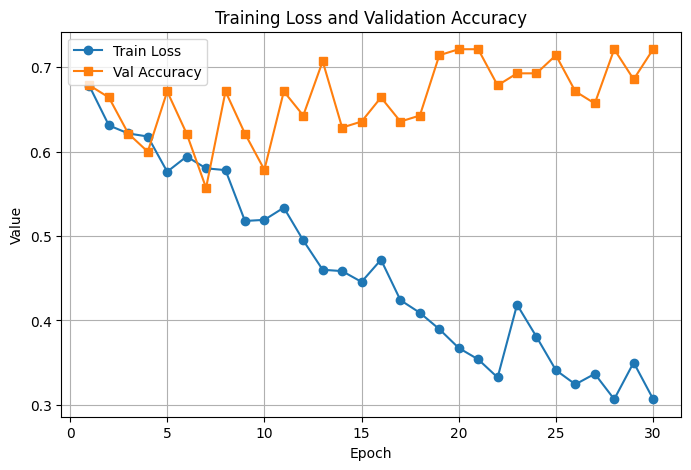

In [16]:
num_epochs = 30

train_losses_spectrogram = []
val_accuracies_spectrogram = []

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader_spectrogram)
    val_acc = eval_epoch(model, val_loader_spectrogram)

    train_losses_spectrogram.append(train_loss)
    val_accuracies_spectrogram.append(val_acc)

    print(f"Epoch {epoch+1:02d} | loss={train_loss:.4f} | val_acc={val_acc:.3f}")

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses_spectrogram, marker='o', label='Train Loss')
plt.plot(epochs, val_accuracies_spectrogram, marker='s', label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training Loss and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
model.eval()
y_true_spectrogram = []
y_pred_spectrogram = []

with torch.no_grad():
    for x, y in test_loader_spectrogram:
        x = x.to(device)
        outputs = model(x)
        preds = outputs.argmax(dim=1).cpu().numpy()

        y_pred_spectrogram.extend(preds)
        y_true_spectrogram.extend(y.numpy())

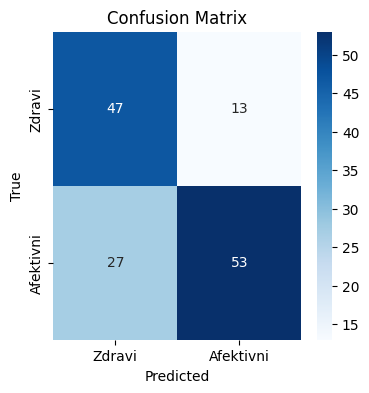

              precision    recall  f1-score   support

      Zdravi       0.64      0.78      0.70        60
   Afektivni       0.80      0.66      0.73        80

    accuracy                           0.71       140
   macro avg       0.72      0.72      0.71       140
weighted avg       0.73      0.71      0.72       140


Accuracy iznosi = 0.7143
F1-score iznosi = 0.7260


In [18]:
cm = confusion_matrix(y_true_spectrogram, y_pred_spectrogram)

plt.figure(figsize=(4,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Zdravi', 'Afektivni'],
    yticklabels=['Zdravi', 'Afektivni']
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(
    classification_report(
        y_true_spectrogram,
        y_pred_spectrogram,
        target_names=['Zdravi', 'Afektivni']
    )
)

TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TP = cm[1,1]

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP + 1e-10)
recall = TP / (TP + FN + 1e-10)
f1 = 2 * (precision * recall) / (precision + recall + 1e-10)

print(f"\nAccuracy iznosi = {accuracy:.4f}")
print(f"F1-score iznosi = {f1:.4f}")